<a href="https://colab.research.google.com/github/Mohammed-Abdul-Rafe-Sajid/Deep-Learning-/blob/main/LAB_5_Simple%20CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CNN MODEL IN KERAS FOR THE MNIST HANDWRITTEN DIGIT  CLASSIFICATION PROBLEM

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 47s 107ms/step - accuracy: 0.9361 - loss: 0.2118 - val_accuracy: 0.9812 - val_loss: 0.0643
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 105ms/step - accuracy: 0.9827 - loss: 0.0572 - val_accuracy: 0.9860 - val_loss: 0.0471
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - accuracy: 0.9867 - loss: 0.0417 - val_accuracy: 0.9875 - val_loss: 0.0434
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.9900 - loss: 0.0315 - val_accuracy: 0.9898 - val_loss: 0.0366
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.9922 - loss: 0.0240 - val_accuracy: 0.9873 - val_loss: 0.0404
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9880 - loss: 0.0390
Test Accuracy: 0.9879999756813049


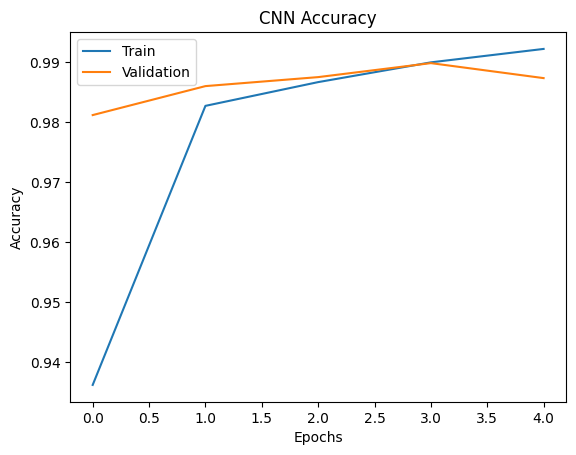

In [1]:
# ==============================================================
# CNN Model for MNIST Handwritten Digit Classification
# ==============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# 1. Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# 2. Normalize (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Reshape for CNN (add channel dimension)
# (28,28) → (28,28,1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# 4. Build CNN model
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 5. Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Train
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

# 7. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# 8. Plot accuracy
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 48s 109ms/step - accuracy: 0.8561 - loss: 0.4946 - val_accuracy: 0.9838 - val_loss: 0.0638
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 79s 102ms/step - accuracy: 0.9795 - loss: 0.0662 - val_accuracy: 0.9878 - val_loss: 0.0470
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 103ms/step - accuracy: 0.9857 - loss: 0.0461 - val_accuracy: 0.9888 - val_loss: 0.0413
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 100ms/step - accuracy: 0.9891 - loss: 0.0343 - val_accuracy: 0.9892 - val_loss: 0.0362
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 0.9921 - loss: 0.0246 - val_accuracy: 0.9907 - val_loss: 0.0318
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 101ms/step - accuracy: 0.9940 - loss: 0.0191 - val_accuracy: 0.9888 - val_loss: 0.0398
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 101ms/step - accuracy: 0.9948 - loss: 0.0178 - val_accuracy: 0.9905 - val_loss: 0.0347
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 100ms/step - accuracy: 0.9953 - loss: 0.

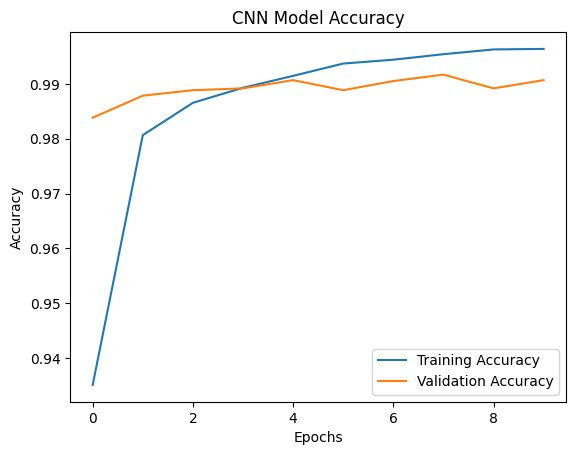

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1
)

test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_accuracy)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("ANN Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()